Model Architecture

* 2D CNN + GRU for IR camera data
* 1D CNN for gas data
* Late stage sensor fusion (concat after encoding)

```
IR Frames (20, 32, 24)                  Gas (20, 3)
        │                                     │
TimeDistributed                          Conv1D(16, k=3)
  Conv2D(8, 3×3) → BN → ReLU            BN → ReLU
  MaxPool(2×2)                           Conv1D(32, k=3)
  Conv2D(16, 3×3) → BN → ReLU           BN → ReLU
  GlobalAvgPool2D                        GlobalAvgPool1D
        │ (20, 16)                            │ (32,)
      GRU(32)
        │ (32,)
        └──────────── Concatenate ───────────┘
                           │ (64,)
                     Dense(64) → BN → ReLU → Dropout(0.4)
                           │
                      Dense(4) → Softmax
```

In [ ]:
!pip install -q matplotlib seaborn scikit-learn

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print(f"TensorFlow version : {tf.__version__}")
tf.config.list_physical_devices('GPU')

TensorFlow version : 2.19.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
# Load data
# Copy data from the raspberry pi
# scp -r isam@192.168.1.109:/home/isam/dev/MLX90640/data_extraction/dataset C:/Users/SamWh/Programming/gas-detector-data
from google.colab import drive
drive.mount("/content/drive")
DATA_ROOT = '/content/drive/MyDrive/gas-data-v1'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
CLASS_NAMES = ["aerosol", "breath", "flame", "normal"]
N_TIMESTEPS  = 20      # 4 Hz × 5 s
IR_H, IR_W   = 32, 24
N_GAS        = 3
N_CLASSES    = len(CLASS_NAMES)

## Data Loading & EDA

In [ ]:
def load_dataset(data_root: str, class_names: list) -> tuple:
    """ Loads all .npz files
      Returns:
        ir_avg    : (32,24)          - Average thermal image
        ir_frames : (N, 20, 32, 24)  — full thermal video sequence
        gas       : (N, 20, 3)       — gas sensor timeseries
        labels    : (N,)             — integer class labels
    """
    ir_avg_list, ir_frames_list, gas_list, label_list = [], [], [], []

    for class_idx, class_name in enumerate(class_names):
      class_dir = os.path.join(data_root, class_name)
      files = sorted(glob.glob(os.path.join(class_dir, "*.npz")))

      if len(files) == 0:
        print(f"No files found for class '{class_name}' in '{class_dir}")
        continue

      print(f"[{class_idx}] {class_name:10s} -> {len(files)} samples")

      for fpath in files:
        data = np.load(fpath)
        ir_avg_list.append(data["ir"].astype(np.float32))  # (32, 24)
        ir_frames_list.append(data["ir_frames"].astype(np.float32))  # (20, 32, 24)
        gas_list.append(data["gas"].astype(np.float32))               # (20, 3)
        label_list.append(class_idx)

    ir_avg    = np.stack(ir_avg_list, axis=0)      # (32, 24)
    ir_frames = np.stack(ir_frames_list, axis=0)   # (N, 20, 32, 24)
    gas       = np.stack(gas_list, axis=0)         # (N, 20, 3)
    labels    = np.array(label_list, dtype=np.int32)


    print(f"Dataset loaded:")
    print(f"   ir_avg shape    : {ir_avg.shape}")
    print(f"   ir_frames shape : {ir_frames.shape}")
    print(f"   gas shape       : {gas.shape}")
    print(f"   labels shape    : {labels.shape}")
    print(f"   Class balance   : {np.bincount(labels)}")
    return ir_avg, ir_frames, gas, labels

print("Loading dataset...")
ir_avg, ir_frames, gas, labels = load_dataset(DATA_ROOT, CLASS_NAMES)


Loading dataset...
[0] aerosol    -> 30 samples
[1] breath     -> 30 samples
[2] flame      -> 30 samples
[3] normal     -> 30 samples
Dataset loaded:
   ir_avg shape    : (120, 32, 24)
   ir_frames shape : (120, 20, 32, 24)
   gas shape       : (120, 20, 3)
   labels shape    : (120,)
   Class balance   : [30 30 30 30]


In [ ]:
def audit_dataset(ir_frames, gas, labels, class_names):
    """
    Audit every sample for NaN, Inf, and constant channels.
    Returns a boolean mask of CLEAN samples.
    """
    print("═" * 55)
    print("  DATA AUDIT")
    print("═" * 55)
    n = len(labels)
    clean_mask = np.ones(n, dtype=bool)

    for i in range(n):
        ir_bad  = not np.isfinite(ir_frames[i]).all()
        gas_bad = not np.isfinite(gas[i]).all()

        if ir_bad or gas_bad:
            clean_mask[i] = False
            cname = class_names[labels[i]]
            print(f"  ⚠️  Sample {i:3d} [{cname}]: "
                  f"IR {'NaN/Inf' if ir_bad else 'OK':8s} | "
                  f"Gas {'NaN/Inf' if gas_bad else 'OK'}")

    n_bad = (~clean_mask).sum()
    n_clean = clean_mask.sum()
    print(f"\n  Total samples : {n}")
    print(f"  Bad  samples  : {n_bad}")
    print(f"  Clean samples : {n_clean}")

    if n_bad > 0:
        print("\n  Class balance AFTER cleaning:")
        clean_labels = labels[clean_mask]
        for ci, cn in enumerate(class_names):
            count = (clean_labels == ci).sum()
            print(f"    [{ci}] {cn:10s}: {count} samples")

    # Also check for constant channels in gas (std == 0 per channel)
    print("\n  Gas channel std (should be > 0 for all):")
    for ch in range(gas.shape[-1]):
        ch_std = gas[:, :, ch][clean_mask].std()
        flag = "⚠️  CONSTANT" if ch_std < 1e-3 else "✅"
        print(f"    Channel {ch}: std = {ch_std:.4f}  {flag}")

    print("═" * 55)
    return clean_mask


clean_mask = audit_dataset(ir_frames, gas, labels, CLASS_NAMES)

# Apply mask — drop bad samples entirely
ir_frames = ir_frames[clean_mask]
gas       = gas[clean_mask]
labels    = labels[clean_mask]

print(f"\nDataset after cleaning: {len(labels)} samples")

═══════════════════════════════════════════════════════
  DATA AUDIT
═══════════════════════════════════════════════════════
  ⚠️  Sample  87 [flame]: IR NaN/Inf  | Gas OK

  Total samples : 120
  Bad  samples  : 1
  Clean samples : 119

  Class balance AFTER cleaning:
    [0] aerosol   : 30 samples
    [1] breath    : 30 samples
    [2] flame     : 29 samples
    [3] normal    : 30 samples

  Gas channel std (should be > 0 for all):
    Channel 0: std = 12517.6172  ✅
    Channel 1: std = 13295.2549  ✅
    Channel 2: std = 27716.7715  ✅
═══════════════════════════════════════════════════════

Dataset after cleaning: 119 samples


Exploratory Visualisation

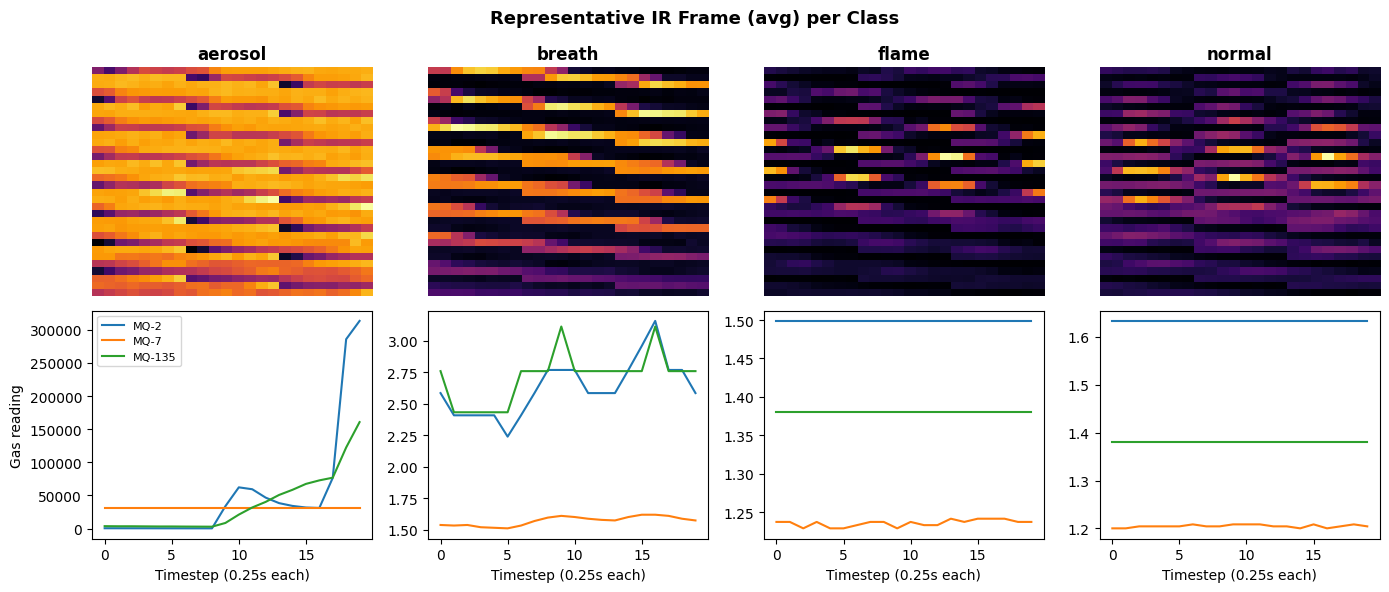

EDA plot saved.


In [ ]:
fig, axes = plt.subplots(2, N_CLASSES, figsize=(14, 6))
fig.suptitle("Representative IR Frame (avg) per Class", fontsize=13, fontweight="bold")

for col, class_name in enumerate(CLASS_NAMES):
    idx = np.where(labels == col)[0][0]

    # Average IR frame across time
    avg_frame = ir_avg[idx]
    axes[0, col].imshow(avg_frame, cmap="inferno", aspect="auto")
    axes[0, col].set_title(class_name, fontweight="bold")
    axes[0, col].axis("off")

    # Gas timeseries
    axes[1, col].plot(gas[idx], label=["MQ-2", "MQ-7", "MQ-135"])
    axes[1, col].set_xlabel("Timestep (0.25s each)")
    if col == 0:
        axes[1, col].set_ylabel("Gas reading")
        axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plot saved.")

Preprocessing & Normalisaiton

# Normalisation strategy:
**IR frames**: per-pixel z-score using training set statistics.
Thermal cameras have a stable absolute temperature range → z-score preserves
the relative temperature gradient that distinguishes classes.

**Gas**: per-channel z-score. Gas sensors have very different absolute ranges
across the 3 channels, normalising each independently prevents one channel
from dominating the loss gradient.

In [ ]:
def compute_normalization_stats(ir_frames_train, gas_train):
    """Compute mean/std on training split only."""
    # IR: mean/std over (N, time, H, W) → result shape (1, 1, H, W) for broadcasting
    ir_mean = ir_frames_train.mean(axis=(0, 1), keepdims=True)   # (1, 1, 32, 24)
    ir_std  = ir_frames_train.std(axis=(0, 1), keepdims=True) + 1e-6

    # Gas: mean/std over (N, time) per channel → (1, 1, 3)
    gas_mean = gas_train.mean(axis=(0, 1), keepdims=True)         # (1, 1, 3)
    gas_std  = gas_train.std(axis=(0, 1), keepdims=True) + 1e-6

    return ir_mean, ir_std, gas_mean, gas_std


def normalize(ir_frames, gas, ir_mean, ir_std, gas_mean, gas_std):
    """Apply z-score normalisation using precomputed statistics."""
    ir_norm  = (ir_frames - ir_mean) / ir_std
    gas_norm = (gas - gas_mean) / gas_std
    return ir_norm, gas_norm

# Data Augmentation

With only 120 samples, data augmentatiom is required to prevent the model learning the training data and over fitting.

### Augmentation strategy:
1. Gaussian noise for IR + gas: Simulates sensor noise, most impactful regulariser
2. Horizontal flip for IR frames: Thermal scene is horizontally symmetric
3. Temporal jitter (±1 frame shift) for IR + gas: Accounts for non-exact alignment at capture start
4. Amplitude scale (0.9-1.1x) for gas: Gas sensors have gain drift between recordings
5. Random frame dropout (set 1-2 frames to mean) for IR: Teaches model not to rely on single frames

In [ ]:
def augment_sample(ir_seq, gas_seq, rng: np.random.Generator):
    """
    Augment a single (ir_seq, gas_seq) pair.
    ir_seq  : (20, 32, 24)
    gas_seq : (20, 3)
    Returns augmented versions of the same shapes.
    """
    ir  = ir_seq.copy()
    gas = gas_seq.copy()

    # 1. Gaussian noise
    if rng.random() > 0.3:
        ir  += rng.normal(0, 0.05, ir.shape).astype(np.float32)
    if rng.random() > 0.3:
        gas += rng.normal(0, 0.03, gas.shape).astype(np.float32)

    # 2. Horizontal flip of IR frames
    if rng.random() > 0.5:
        ir = ir[:, :, ::-1]   # flip width axis

    # 3. Temporal jitter: shift by ±1 timestep with zero-padding
    if rng.random() > 0.5:
        shift = rng.integers(-1, 2)  # -1, 0, or +1
        if shift != 0:
            ir  = np.roll(ir,  shift, axis=0)
            gas = np.roll(gas, shift, axis=0)
            if shift > 0:
                ir[:shift]  = 0;  gas[:shift]  = 0
            else:
                ir[shift:]  = 0;  gas[shift:]  = 0

    # 4. Gas amplitude scale
    if rng.random() > 0.4:
        scale = rng.uniform(0.9, 1.1)
        gas  *= scale

    # 5. Random IR frame dropout (replace 1-2 frames with channel mean)
    if rng.random() > 0.5:
        n_drop = rng.integers(1, 3)
        drop_idx = rng.choice(20, n_drop, replace=False)
        for d in drop_idx:
            ir[d] = ir.mean(axis=0)

    return ir.astype(np.float32), gas.astype(np.float32)

def augment_batch(ir_batch, gas_batch, n_aug_per_sample=3, seed=42):
    """
    Augment every sample in a batch n_aug_per_sample times.
    Returns the original + augmented data concatenated.
    """
    rng = np.random.default_rng(seed)
    aug_ir, aug_gas = [ir_batch], [gas_batch]

    for _ in range(n_aug_per_sample):
        new_ir  = np.zeros_like(ir_batch)
        new_gas = np.zeros_like(gas_batch)
        for i in range(len(ir_batch)):
            new_ir[i], new_gas[i] = augment_sample(ir_batch[i], gas_batch[i], rng)
        aug_ir.append(new_ir)
        aug_gas.append(new_gas)

    return np.concatenate(aug_ir), np.concatenate(aug_gas)


# Model Architecture

The model has two input branches that are fused before the classification head. The model is kept small (~12K parameters) to avoid overfitting

In [ ]:
def build_model(n_timesteps=20,ir_h=32, ir_w=24,n_gas=3,
                n_classes=4,l2_lambda=1e-4, tflite_export=False) -> tf.keras.Model:

    # This creates an L2 regulariser, which adds a penalty to the loss based on
    # the size of the model’s weights. helps prevent over fitting
    reg = tf.keras.regularizers.l2(l2_lambda)

    # ------------------------------ IR Branch ------------------------------
    # Input dimensions: (20, 32, 24)
    ir_input = tf.keras.Input(shape=(n_timesteps, ir_h, ir_w), name="ir_frames")

    # Add a channel dimension (B,20,32,24,1)
    x = tf.keras.layers.Reshape((n_timesteps, ir_h, ir_w, 1))(ir_input)

    # LAYER 1
    # TimeDistributed CNN: same CNN applied to each of the 20 frames
    # num of filters = 8
    # kernel size = 3x3
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(8,
                                        (3, 3), padding="same",
                                        kernel_regularizer=reg), name="td_conv1")(x)

    # Batch Normalization (keeps intermediate features centered and scaled)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)

    # Introduce no linearity and prevent vanishing gradients
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.ReLU())(x)

    # Max Pooling - downsampling
    # Look at every 2x2 block and keep the highest activation value
    # [1  5]
    # [2  3]   →   5
    # (B, 20, 16, 12, 8)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPool2D((2, 2)),name="td_pool1")(x)

    # LAYER 2
    # 2nd 2D CNN
    # num of filters = 16
    # kernel size = 3x3
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(16,
                                        (3, 3), padding="same",
                                        kernel_regularizer=reg), name="td_conv2")(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.ReLU())(x)

    # GlobalAveragePooling (B, 20, 16)
    # For each channel (output of a filter) calculate average activation over the whole image
    # Compresses channel activation into a 16 dimension summary vector
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.GlobalAveragePooling2D(),name="td_gap")(x)

    # Gated Recurrent Unit (GRU) - a type of RNN that learns patterns over time
    # GRUs have gates that control information flow:
    # Update gate → how much new info to add
    # Reset gate → how much past info to forget

    # GRU for temporal modelling of IR feature sequence (B, 32)
    # x = tf.keras.layers.GRU(32,
    #                         return_sequences=False,
    #                         kernel_regularizer=reg,
    #                         name="ir_gru",
    #                         implementation=1 if tflite_export else 2,
    #                         unroll=tflite_export
    #                         )(x)
    if tflite_export:
        # Explicit RNN+GRUCell unrolls cleanly to static ops for TFLite
        gru_cell = tf.keras.layers.GRUCell(
            32,
            kernel_regularizer=reg,
            name="ir_gru_cell"
        )
        x = tf.keras.layers.RNN(
            gru_cell,
            return_sequences=False,
            unroll=True,           # forces fully static graph
            name="ir_gru"
        )(x)
    else:
        # Standard GRU — uses CuDNN on GPU during training
        x = tf.keras.layers.GRU(
            32,
            return_sequences=False,
            kernel_regularizer=reg,
            name="ir_gru"
        )(x)


    # Randomly zero 30% of inputs - prevents overfitting in training and improves generalisation
    x = tf.keras.layers.Dropout(0.3)(x)

    ir_features = x  # (B, 32)


    # ------------------------------ Gas Branch ------------------------------
    # Input: (batch, 20, 3)
    gas_input = tf.keras.Input(shape=(n_timesteps, n_gas), name="gas")
    g = tf.keras.layers.Conv1D(16, 3, padding="same", kernel_regularizer=reg, name="gas_conv1")(gas_input)
    g = tf.keras.layers.BatchNormalization()(g)
    g = tf.keras.layers.ReLU()(g)
    g = tf.keras.layers.Conv1D(32, 3, padding="same", kernel_regularizer=reg, name="gas_conv2")(g)
    g = tf.keras.layers.BatchNormalization()(g)
    g = tf.keras.layers.ReLU()(g)
    g = tf.keras.layers.GlobalAveragePooling1D(name="gas_gap")(g)   # (B, 32)
    g = tf.keras.layers.Dropout(0.3)(g)
    gas_features = g  # (B, 32)

    # ------------------------------ Fusion Head ------------------------------
    fused = tf.keras.layers.Concatenate(name="fusion")([ir_features, gas_features])  # (B, 64)
    fused = tf.keras.layers.Dense(64, kernel_regularizer=reg, name="fc1")(fused)
    fused = tf.keras.layers.BatchNormalization()(fused)
    fused = tf.keras.layers.ReLU()(fused)
    fused = tf.keras.layers.Dropout(0.4)(fused)
    output = tf.keras.layers.Dense(n_classes, activation="softmax", name="output")(fused)

    model = tf.keras.Model(inputs={"ir_frames": ir_input, "gas": gas_input},
                           outputs=output, name="SensorFusionClassifier")
    return model

# Print summary
model_preview = build_model()
model_preview.summary()
print(f"\nTotal parameters: {model_preview.count_params():,}")

# tf.keras.utils.plot_model(model_preview, show_shapes=True, dpi=100)


Model: "SensorFusionClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ir_frames           │ (None, 20, 32,    │          0 │ -                 │
│ (InputLayer)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 20, 32,    │          0 │ ir_frames[0][0]   │
│                     │ 24, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_conv1            │ (None, 20, 32,    │         80 │ reshape[0][0]     │
│ (TimeDistributed)   │ 24, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 20, 32,    │         32 │ td_conv1[0][0]    │
│ (TimeDistributed)   │ 24, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gas (InputLayer)    │ (None, 20, 3)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 20, 32,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 24, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gas_conv1 (Conv1D)  │ (None, 20, 16)    │        160 │ gas[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_pool1            │ (None, 20, 16,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 12, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 16)    │         64 │ gas_conv1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_conv2            │ (None, 20, 16,    │      1,168 │ td_pool1[0][0]    │
│ (TimeDistributed)   │ 12, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 20, 16)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 20, 16,    │         64 │ td_conv2[0][0]    │
│ (TimeDistributed)   │ 12, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gas_conv2 (Conv1D)  │ (None, 20, 32)    │      1,568 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 20, 16,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 12, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 32)    │        128 │ gas_conv2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_gap              │ (None, 20, 16)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 20, 32)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ir_gru (GRU)        │ (None, 32)        │      4,800 │ td_gap[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gas_gap             │ (None, 32)        │          0 │ re_lu_3[0][0]   

 Total params: 12,740 (49.77 KB)

 Trainable params: 12,468 (48.70 KB)

 Non-trainable params: 272 (1.06 KB)


Total parameters: 12,740


# Training with Stratified 5-Fold Cross Validation
### Why K-Fold instead of a single train/val split?
With 30 samples per class, a single 80/20 split gives only ~6 val samples per class which is far too few to estimate generalisation reliably. 5-fold CV trains 5 models and averages, giving a robust estimate. T5 Fold CV helps find hyperparameters that we can use when training the single model eg number of epochs.


In [ ]:
# Hyperparameters
N_FOLDS          = 5      # Number of folds
N_AUG_PER_SAMPLE = 3      # training set becomes 4× the original size per fold
BATCH_SIZE       = 16
EPOCHS           = 120
LR               = 3e-4   # Learning rate
L2_LAMBDA        = 1e-4   # strength of L2 regularisation. How strongly you penalise large weights in your model.

CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:
def make_callbacks(fold_id: int, checkpoint_dir: str) -> list:
    """Callbacks: checkpoint best model + reduce LR on plateau + early stopping."""
    ckpt_path = os.path.join(checkpoint_dir, f"fold_{fold_id}_best.keras")
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=12,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=25,
            restore_best_weights=True,
            verbose=1
        )
    ]

In [ ]:
# Train 5 fold cross validation

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_histories  = []
fold_val_accs   = []
fold_val_losses = []

print(f"Starting {N_FOLDS}-Fold Cross Validation")

print(f"Augmentation: {N_AUG_PER_SAMPLE}× per sample "
      f"~{int(len(labels) * 0.8) * (N_AUG_PER_SAMPLE + 1)} training samples per fold\n")

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(ir_frames, labels)):
    print(f"{'═'*60}")
    print(f"FOLD {fold_idx + 1} / {N_FOLDS}")
    print(f"Train: {len(train_idx)} samples | Val: {len(val_idx)} samples")
    print(f"{'═'*60}")

    # ── Split ─────────────────────────────────────────────────────────────────
    ir_train_raw  = ir_frames[train_idx]
    gas_train_raw = gas[train_idx]
    y_train_raw   = labels[train_idx]

    ir_val_raw    = ir_frames[val_idx]
    gas_val_raw   = gas[val_idx]
    y_val         = labels[val_idx]

    # ── Normalise (fit on train only) ─────────────────────────────────────────
    ir_mean, ir_std, gas_mean, gas_std = compute_normalization_stats(
        ir_train_raw, gas_train_raw
    )
    ir_train_norm, gas_train_norm = normalize(
        ir_train_raw, gas_train_raw, ir_mean, ir_std, gas_mean, gas_std
    )
    ir_val_norm, gas_val_norm = normalize(
        ir_val_raw, gas_val_raw, ir_mean, ir_std, gas_mean, gas_std
    )

    # ── Augment training data ─────────────────────────────────────────────────
    ir_train_aug, gas_train_aug = augment_batch(
        ir_train_norm, gas_train_norm,
        n_aug_per_sample=N_AUG_PER_SAMPLE,
        seed=SEED + fold_idx
    )
    y_train_aug = np.tile(y_train_raw, N_AUG_PER_SAMPLE + 1)

    # Shuffle augmented training set
    perm = np.random.permutation(len(y_train_aug))
    ir_train_aug  = ir_train_aug[perm]
    gas_train_aug = gas_train_aug[perm]
    y_train_aug   = y_train_aug[perm]

    print(f" Augmented training size: {len(y_train_aug)}")

    # ── Build & compile fresh model ───────────────────────────────────────────
    model = build_model(l2_lambda=L2_LAMBDA)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # ── Train ─────────────────────────────────────────────────────────────────
    history = model.fit(
        x={"ir_frames": ir_train_aug, "gas": gas_train_aug},
        y=y_train_aug,
        validation_data=(
            {"ir_frames": ir_val_norm, "gas": gas_val_norm},
            y_val
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(fold_idx, CHECKPOINT_DIR),
        verbose=1
    )

    fold_histories.append(history.history)
    best_val_acc  = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])
    fold_val_accs.append(best_val_acc)
    fold_val_losses.append(best_val_loss)
    print(f"Fold {fold_idx+1} best val accuracy: {best_val_acc:.4f}")
    print(f"Fold {fold_idx+1} best val loss: {best_val_loss:.4f}")


Starting 5-Fold Cross Validation
Augmentation: 3× per sample ~380 training samples per fold

════════════════════════════════════════════════════════════
FOLD 1 / 5
Train: 95 samples | Val: 24 samples
════════════════════════════════════════════════════════════
 Augmented training size: 380
Epoch 1/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 192ms/step - accuracy: 0.4000 - loss: 1.4186 - val_accuracy: 0.5417 - val_loss: 1.2937 - learning_rate: 3.0000e-04
Epoch 2/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5474 - loss: 1.0360 - val_accuracy: 0.6667 - val_loss: 1.1971 - learning_rate: 3.0000e-04
Epoch 3/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6474 - loss: 0.8796 - val_accuracy: 0.7917 - val_loss: 1.0917 - learning_rate: 3.0000e-04
Epoch 4/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7421 - loss: 0.7074 - val_accuracy: 0.8333 - val_loss: 0.9723 - learning_rate: 3.0000e-04
Epoch 5/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7974 - loss: 0.6

## 5 Fold CV Training Curves

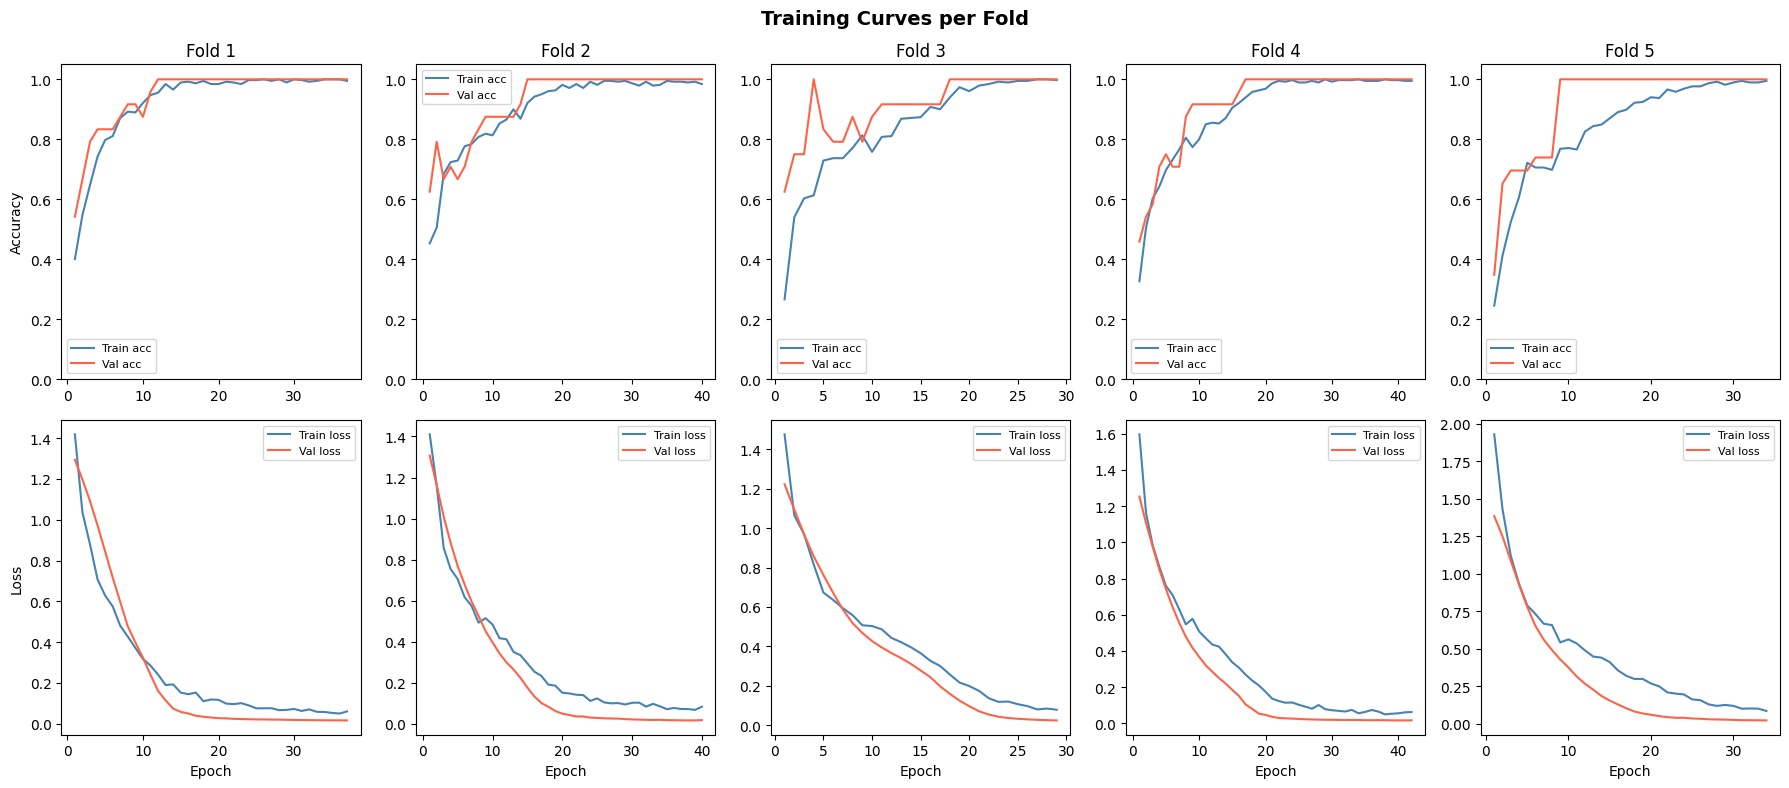

In [ ]:
fig, axes = plt.subplots(2, N_FOLDS, figsize=(18, 8))
fig.suptitle("Training Curves per Fold", fontsize=14, fontweight="bold")

for fold_idx, hist in enumerate(fold_histories):
    epochs_ran = range(1, len(hist["accuracy"]) + 1)

    axes[0, fold_idx].plot(epochs_ran, hist["accuracy"],     label="Train acc", color="steelblue")
    axes[0, fold_idx].plot(epochs_ran, hist["val_accuracy"], label="Val acc",   color="tomato")
    axes[0, fold_idx].set_title(f"Fold {fold_idx+1}")
    axes[0, fold_idx].set_ylim([0, 1.05])
    axes[0, fold_idx].legend(fontsize=8)
    if fold_idx == 0:
        axes[0, fold_idx].set_ylabel("Accuracy")

    axes[1, fold_idx].plot(epochs_ran, hist["loss"],     label="Train loss", color="steelblue")
    axes[1, fold_idx].plot(epochs_ran, hist["val_loss"], label="Val loss",   color="tomato")
    axes[1, fold_idx].legend(fontsize=8)
    if fold_idx == 0:
        axes[1, fold_idx].set_ylabel("Loss")
    axes[1, fold_idx].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Ensemble 5 Fold Best Predictions

We Previously trained 5 models on
* 80% of the data

Now we can test on the 20% validation set and calcuate model accuracy



In [ ]:
oof_preds  = np.zeros((len(labels), N_CLASSES))  # out-of-fold softmax probs
oof_labels = labels.copy()

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(ir_frames, labels)):
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"fold_{fold_idx}_best.keras")
    fold_model = tf.keras.models.load_model(ckpt_path)

    ir_val_raw  = ir_frames[val_idx]
    gas_val_raw = gas[val_idx]

    # Recompute norm stats for this fold
    ir_mean, ir_std, gas_mean, gas_std = compute_normalization_stats(
        ir_frames[train_idx], gas[train_idx]
    )
    ir_val_norm, gas_val_norm = normalize(
        ir_val_raw, gas_val_raw, ir_mean, ir_std, gas_mean, gas_std
    )

    preds = fold_model.predict(
        {"ir_frames": ir_val_norm, "gas": gas_val_norm}, verbose=0
    )
    oof_preds[val_idx] = preds
    print(f"Fold {fold_idx+1} OOF predictions collected.")

oof_pred_classes = np.argmax(oof_preds, axis=1)
oof_accuracy = (oof_pred_classes == oof_labels).mean()
print(f"Out-of-fold ensemble accuracy: {oof_accuracy:.4f}")


Fold 1 OOF predictions collected.
Fold 2 OOF predictions collected.
Fold 3 OOF predictions collected.
Fold 4 OOF predictions collected.


Fold 5 OOF predictions collected.
Out-of-fold ensemble accuracy: 1.0000


## Confusion matrix


══════════════════════════════════════════════════
CLASSIFICATION REPORT (Out-of-Fold)
══════════════════════════════════════════════════
              precision    recall  f1-score   support

     aerosol       1.00      1.00      1.00        30
      breath       1.00      1.00      1.00        30
       flame       1.00      1.00      1.00        29
      normal       1.00      1.00      1.00        30

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119



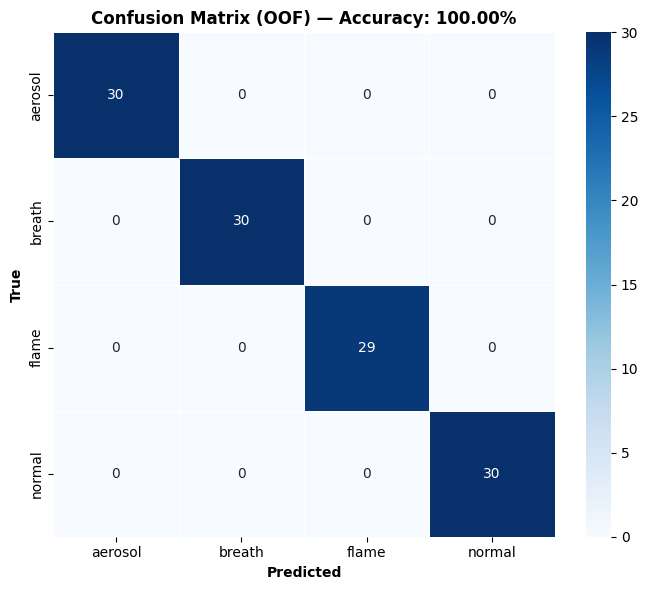

In [ ]:
print("\n" + "═"*50)
print("CLASSIFICATION REPORT (Out-of-Fold)")
print("═"*50)
print(classification_report(
    oof_labels, oof_pred_classes,
    target_names=CLASS_NAMES
))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(oof_labels, oof_pred_classes)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel("Predicted", fontweight="bold")
ax.set_ylabel("True",      fontweight="bold")
ax.set_title(f"Confusion Matrix (OOF) — Accuracy: {oof_accuracy:.2%}", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Train Deployment Model on Full Dataset

This is the model used for deployment. It trains on all 120 samples. The number of epochs is decided by looking at when the validation loss plateaued across the 5 folds.

In [ ]:
# Compute the normalization stats on the full dataset
ir_mean_full, ir_std_full, gas_mean_full, gas_std_full = compute_normalization_stats(
    ir_frames, gas
)
ir_norm_full, gas_norm_full = normalize(
    ir_frames, gas, ir_mean_full, ir_std_full, gas_mean_full, gas_std_full
)

# Augement the full dataset
ir_full_aug, gas_full_aug = augment_batch(
    ir_norm_full, gas_norm_full, n_aug_per_sample=4, seed=SEED
)

# Shuffle the dataset
y_full_aug = np.tile(labels, 5)
perm = np.random.permutation(len(y_full_aug))
ir_full_aug  = ir_full_aug[perm]
gas_full_aug = gas_full_aug[perm]
y_full_aug   = y_full_aug[perm]

# Estimate good epoch count from CV (average of best epochs)
avg_best_epoch = int(np.mean([
    np.argmax(h["val_accuracy"]) + 1 for h in fold_histories
]))

# Add a small buffer since we now have more data
FINAL_EPOCHS = int(avg_best_epoch * 1.2)

print(f"Training final model for {FINAL_EPOCHS} epochs (CV mean best: {avg_best_epoch})")

final_model = build_model(l2_lambda=L2_LAMBDA)
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_ckpt = os.path.join(CHECKPOINT_DIR, "final_model.keras")

final_history = final_model.fit(x={"ir_frames": ir_full_aug, "gas": gas_full_aug},
      y=y_full_aug, epochs=FINAL_EPOCHS, batch_size=BATCH_SIZE,
      callbacks=[
          tf.keras.callbacks.ModelCheckpoint(
              final_ckpt, monitor="accuracy", save_best_only=True, verbose=0
          ),
          tf.keras.callbacks.ReduceLROnPlateau(
              monitor="loss", factor=0.5, patience=10, min_lr=1e-6, verbose=1
          )
      ],
      verbose=1
)

final_model = tf.keras.models.load_model(final_ckpt)
print("Final model trained and saved.")


Training final model for 13 epochs (CV mean best: 11)
Epoch 1/13
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.3798 - loss: 1.4695 - learning_rate: 3.0000e-04
Epoch 2/13
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5849 - loss: 1.0146 - learning_rate: 3.0000e-04
Epoch 3/13
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6824 - loss: 0.8242 - learning_rate: 3.0000e-04
Epoch 4/13
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7630 - loss: 0.6356 - learning_rate: 3.0000e-04
Epoch 5/13
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.7815 - loss: 0.5720 - learning_rate: 3.0000e-04
Epoch 6/13
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8454 - loss: 0.4994 - learning_rate: 3.0000e-04
Epoch 7/13
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8689 - loss: 0.4361 - learning_rate: 3.0000e-04
Epoch 8/13
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9008 - loss: 0.3750 - learning_rate: 3.0000e-04
Epoch 9/13
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 

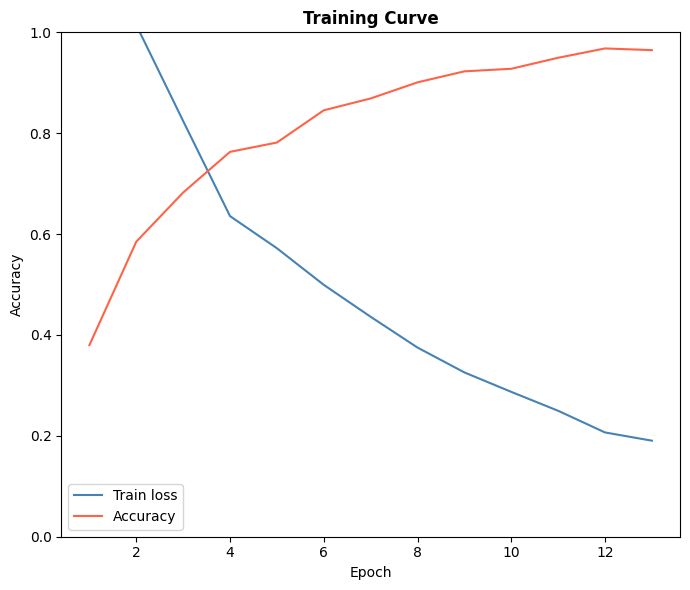

In [ ]:
# final_history
fig, axes = plt.subplots(figsize=(7, 6))
axes.set_title(f"Training Curve", fontweight="bold")

epochs_ran = range(1, len(final_history.history["accuracy"]) + 1)

axes.plot(epochs_ran, final_history.history["loss"], label="Train loss", color="steelblue")
axes.plot(epochs_ran, final_history.history["accuracy"], label="Accuracy",   color="tomato")

axes.set_ylim(0, 1)
axes.set_xlabel("Epoch")
axes.set_ylabel("Accuracy")

axes.legend()

plt.tight_layout()
plt.show()

# Save Normalisation Statistics

The mean/std used to normalise inputs must be saved and deployed alongside the model.

In [ ]:
STATS_PATH = "/content/drive/MyDrive/gas-detector-model/model_stats/"
os.makedirs(STATS_PATH, exist_ok=True)

np.savez(
    f"{STATS_PATH}/norm_stats.npz",
    ir_mean=ir_mean_full,
    ir_std=ir_std_full,
    gas_mean=gas_mean_full,
    gas_std=gas_std_full
)

# Convert to CSV
df = pd.DataFrame({
    "ir_mean": [ir_mean_full.tolist()],
    "ir_std": [ir_std_full.tolist()],
    "gas_mean": [gas_mean_full.tolist()],
    "gas_std": [gas_std_full.tolist()],
})

df.to_csv(f"{STATS_PATH}/norm_stats.csv", index=False)

print(f"Normalisation stats saved")

print(f"  ir_mean shape  : {ir_mean_full.shape}")
print(f"  ir_std shape   : {ir_std_full.shape}")
print(f"  gas_mean shape : {gas_mean_full.shape}")
print(f"  gas_std shape  : {gas_std_full.shape}")

Normalisation stats saved
  ir_mean shape  : (1, 1, 32, 24)
  ir_std shape   : (1, 1, 32, 24)
  gas_mean shape : (1, 1, 3)
  gas_std shape  : (1, 1, 3)


## TFlite Conversion & Quantisation

Export 2 variants of the model and compare accuracy
1. Float32: 214.9 KB
2. Float16: 193.4 KB


In [ ]:
import keras
TFLITE_DIR = "/content/drive/MyDrive/gas-detector-model/tflite_models"
os.makedirs(TFLITE_DIR, exist_ok=True)

# Load trained model (may use CuDNN GRU if GPU is visible)
print("Loading trained model...")
trained_model = keras.models.load_model("/content/checkpoints/final_model.keras", compile=False)

# Build a CPU-compatible version of the model and transfer weights
print("Building CPU-compatible model and transferring weights...")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
export_model = build_model(tflite_export=True)
export_model.set_weights(trained_model.get_weights())

# Export to SavedModel format
print("Exporting to SavedModel...")
export_model.export("saved_model_cpu")

def convert(path, desc, optimizations=None, float16=False):
    converter = tf.lite.TFLiteConverter.from_saved_model("saved_model_cpu")

    # Standard ops only - if this fails, the model still has dynamic ops
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

    if optimizations:
        converter.optimizations = optimizations
    if float16:
        converter.target_spec.supported_types = [tf.float16]

    tflite_model = converter.convert()

    with open(path, "wb") as f:
        f.write(tflite_model)
    print(f"{desc}: {os.path.getsize(path)/1024:.1f} KB")
    return tflite_model

# Float32 (baseline)
tflite_f32 = convert(
    f"{TFLITE_DIR}/model_float32.tflite",
    "Float32"
)

# Float16
tflite_f16 = convert(
    f"{TFLITE_DIR}/model_float16.tflite",
    "Float16",
    optimizations=[tf.lite.Optimize.DEFAULT],
    float16=True
)

Loading trained model...
Building CPU-compatible model and transferring weights...
Exporting to SavedModel...
Saved artifact at 'saved_model_cpu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['ir_frames', TensorSpec(shape=(None, 20, 32, 24), dtype=tf.float32, name='ir_frames')], ['gas', TensorSpec(shape=(None, 20, 3), dtype=tf.float32, name='gas')]]
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137491414650704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137491511817616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137491511817232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137491511808016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137491511804368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137491511807248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137491511809360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137491511807056: TensorSpe

# Inspect tflite file operations

The inspection output shows the model fully unrolled and converted to pure TFLite ops. Here's what you're seeing:

Inputs (indices 0-1)
Two named inputs matching exactly what was defined in build_model:

serving_default_gas:0 → shape [1, 20, 3]
serving_default_ir_frames:0 → shape [1, 20, 32, 24]

The batch dimension is fixed at 1, meaning the model is optimised for single-sample inference.

Output (index 457 → StatefulPartitionedCall_1:0)
Shape [1, 4] — one probability per class, softmax already applied. You just take argmax to get the predicted class.

Weights/constants (indices 2-34)
The fused layer weights — notice TFLite has merged BatchNorm into the preceding Conv layers (e.g. index 4 shows td_conv2 and batch_normalization_61 fused together). This is a TFLite optimisation called operator fusion — it eliminates the separate BN multiply/add at runtime by baking the BN parameters directly into the conv weights, making inference faster.

GRU unrolled (indices 54-455)
This is the big block — you can see the GRU is literally repeated 20 times (Tanh_0 through Tanh_19, Sigmoid_0 through Sigmoid_39, etc.), one full GRU cell computation per timestep. Each timestep has the same pattern:

MatMul → split (z, r, h gates) → Sigmoid → Sigmoid → mul → Tanh → add

This is exactly what unroll=True does — it trades graph size for no dynamic ops. The 127 KB vs 68 KB size difference is entirely from this repetition.


In [ ]:
def inspect_tflite(path):
    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()

    print(f"\n{'='*50}")
    print(f"Model: {path}")
    print(f"{'='*50}")

    print("\n--- Inputs ---")
    for t in interpreter.get_input_details():
        print(f"  {t['name']}: shape={t['shape']}, dtype={t['dtype']}")

    print("\n--- Outputs ---")
    for t in interpreter.get_output_details():
        print(f"  {t['name']}: shape={t['shape']}, dtype={t['dtype']}")

    print("\n--- All Tensors ---")
    for t in interpreter.get_tensor_details():
        print(f"  [{t['index']:3d}] {t['name']:<60} shape={t['shape']}, dtype={t['dtype']}")

inspect_tflite(f"{TFLITE_DIR}/model_float32.tflite")
inspect_tflite(f"{TFLITE_DIR}/model_float16.tflite")


Model: /content/drive/MyDrive/gas-detector-model/tflite_models/model_float32.tflite

--- Inputs ---
  serving_default_gas:0: shape=[ 1 20  3], dtype=<class 'numpy.float32'>
  serving_default_ir_frames:0: shape=[ 1 20 32 24], dtype=<class 'numpy.float32'>

--- Outputs ---
  StatefulPartitionedCall_1:0: shape=[1 4], dtype=<class 'numpy.float32'>

--- All Tensors ---
  [  0] serving_default_gas:0                                        shape=[ 1 20  3], dtype=<class 'numpy.float32'>
  [  1] serving_default_ir_frames:0                                  shape=[ 1 20 32 24], dtype=<class 'numpy.float32'>
  [  2] arith.constant                                               shape=[32], dtype=<class 'numpy.float32'>
  [  3] arith.constant1                                              shape=[16], dtype=<class 'numpy.float32'>
  [  4] arith.constant2                                              shape=[32  1  3 16], dtype=<class 'numpy.float32'>
  [  5] arith.constant3                              

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
